In [1]:
import numpy as np
import matplotlib.pyplot as plt

import os
os.environ["RUST_BACKTRACE"] = "1"

from py_rust_glm import LinearRegression, LogisticRegression, PoissonRegression

In [2]:
N = 50_000
D = 10
σ = 1.0

## Linear Regression

In [3]:
X = np.zeros(shape=(N, D+1))
X[:, 0] = 1.0
X[:, 1:] = np.random.normal(0.0, 10.0, size=(N, D))

β = np.random.uniform(-2.0, 2.0, size=D+1)

y = X @ β + np.random.normal(0.0, σ, size=N)

In [4]:
lr = LinearRegression()
lr.fit(X, y)

In [5]:
y_hat = lr.predict(X)

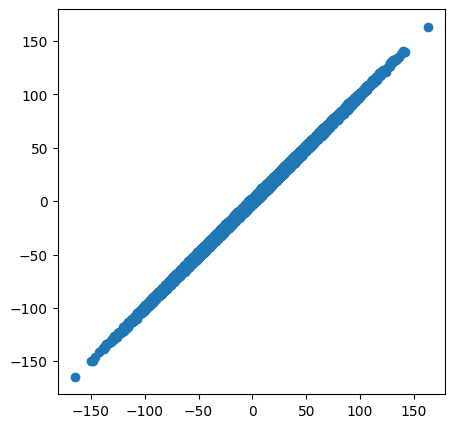

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(y, y_hat)

## Logistic Regression

In [7]:
def sigmoid(t): return 1 / (1 + np.exp(-t))

X = np.zeros(shape=(N, D+1))
X[:, 0] = 1.0
X[:, 1:] = np.random.normal(0.0, 10.0, size=(N, D))

β = np.random.uniform(-2.0, 2.0, size=D+1)

nu = X @ β
y = np.random.binomial(1, sigmoid(nu)).astype(np.float64)

In [8]:
logr = LogisticRegression()
logr.fit(X, y)

In [9]:
β

array([ 0.94791877,  0.8655543 ,  1.1539666 , -1.46768984, -0.63536807,
        0.52069559,  1.00798069, -0.36962165, -0.37296145,  0.64724214,
        1.19847822])

In [10]:
logr.coef_

array([ 0.93461016,  0.85336749,  1.14752796, -1.45522953, -0.62166052,
        0.51480056,  0.99943557, -0.37020504, -0.37104271,  0.63935154,
        1.18196749])

## Poisson Regression

In [11]:
def sigmoid(t): return 1 / (1 + np.exp(-t))

X = np.zeros(shape=(N, D+1))
X[:, 0] = 1.0
X[:, 1:] = np.random.normal(1.0, 0.5, size=(N, D))

t = np.random.uniform(0, 100.0, size=N)
β = np.random.uniform(-1.0, -0.0, size=D+1)

nu = X @ β
y = np.random.poisson(t * np.exp(nu)).astype(np.float64)

In [12]:
t * np.exp(nu)

array([0.49993049, 0.02430349, 0.39700715, ..., 0.50007476, 0.07598989,
       0.80549776], shape=(50000,))

In [13]:
nu

array([-5.15907256, -5.95002833, -5.4189073 , ..., -5.05970696,
       -6.23422944, -3.89454392], shape=(50000,))

In [14]:
y.max()

np.float64(20.0)

In [15]:
poisr = PoissonRegression()
poisr.fit(X, y, t)

In [16]:
poisr.coef_

array([-0.86808233, -0.80659743, -0.42403323, -0.18113925, -0.53249969,
       -0.14697398, -0.09302128, -0.41188966, -0.37968521, -0.37269058,
       -0.97515127])

In [17]:
β

array([-0.82453572, -0.82280876, -0.44376192, -0.1680865 , -0.55026525,
       -0.16453967, -0.08937516, -0.41983433, -0.38780122, -0.36967752,
       -0.95757492])